# Wine
- Number of Instances: 178
- Number of Attributes: 13 numeric, predictive attributes and the class
- Attribute Information:
    1. Alcohol 酒精含量 %
    2. Malic acid 蘋果酸含量 g/L (酸度)
    3. Ash 灰分 g/L (礦物質殘留)
    4. Alcalinity of ash (礦物質酸鹼度)
    5. Magnesium 鎂含量 ppm (礦物質結構)
    6. Total phenols 酚含量(苦味, 抗氧化)
    7. Flavanoids 類黃酮含量(苦味, 結構)
    8. Nonflavanoid phenols 非類黃酮含量(結構, 影響小)
    9. Proanthocyanins 原花青素(顏色, 結構)
    10. Color intensity 顏色飽和度
    11. Hue 色調(紅酒低, 白酒高)
    12. OD280/OD315 of diluted wines 波長測量的光學密度(評估酚類含量)
    13. Proline 脯氨酸含量 mg/L (香氣)


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [3]:
wine = load_wine()
data = pd.DataFrame(wine.data, columns=wine.feature_names)
data['Class'] = wine.target
features = data.drop(columns='Class')
target = data['Class']

In [4]:
features.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
target.value_counts()

Class
1    71
0    59
2    48
Name: count, dtype: int64

In [6]:
features.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [7]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


---

# HistPlot

# 紅: Class 1, 藍: Class 2, 綠: Class 0

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


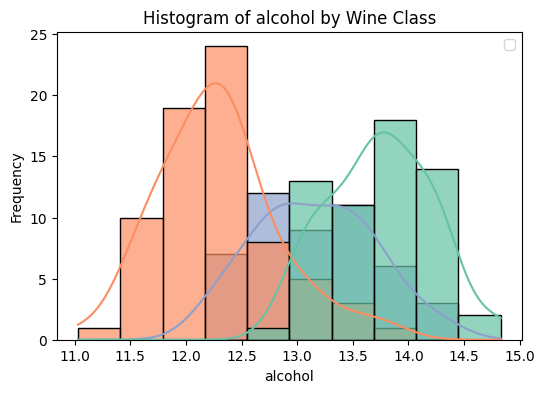

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


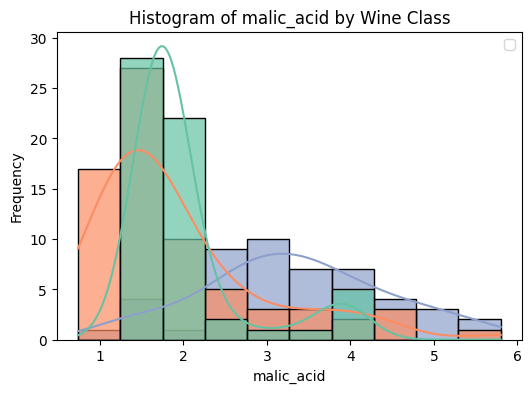

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


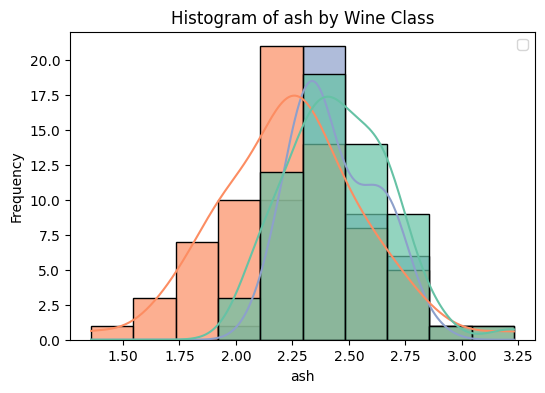

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


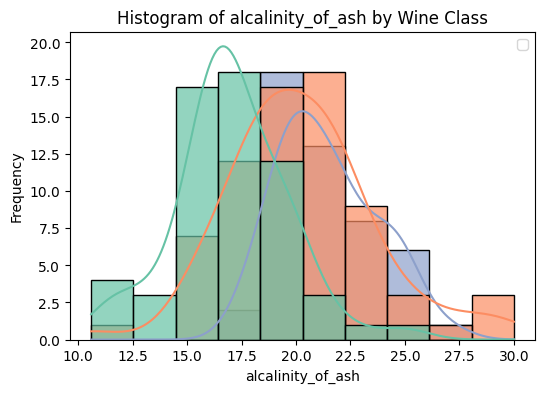

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


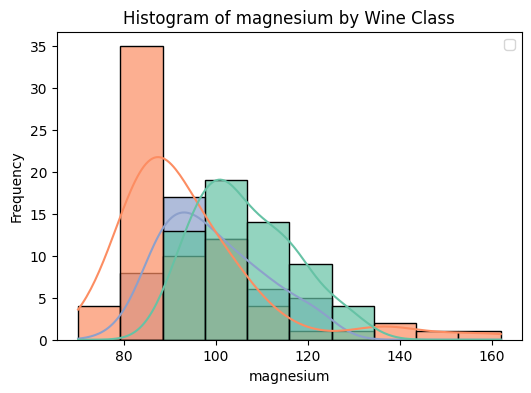

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


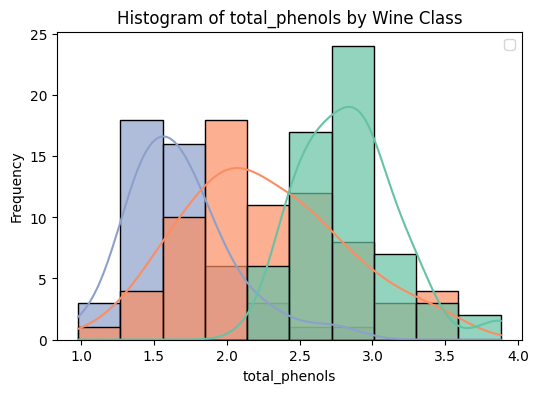

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


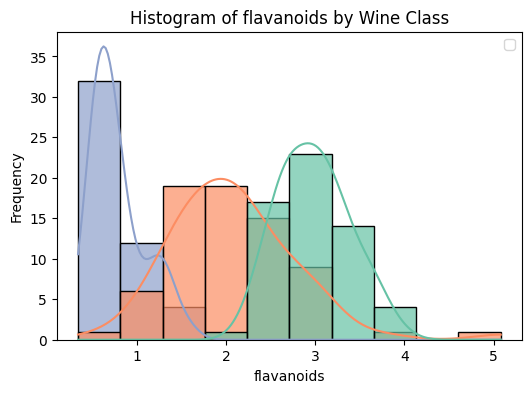

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


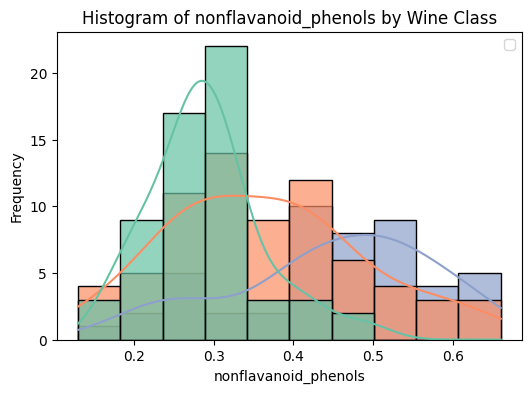

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


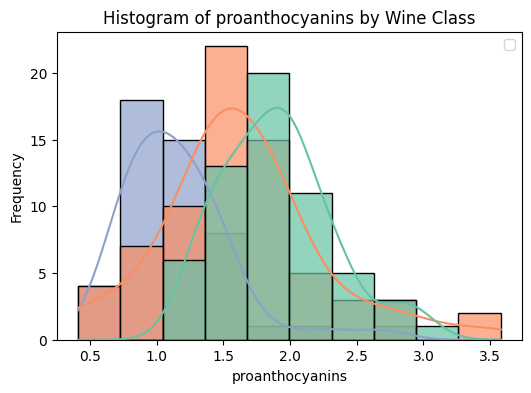

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


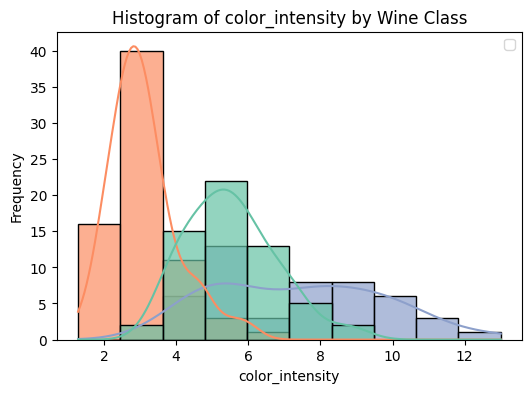

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


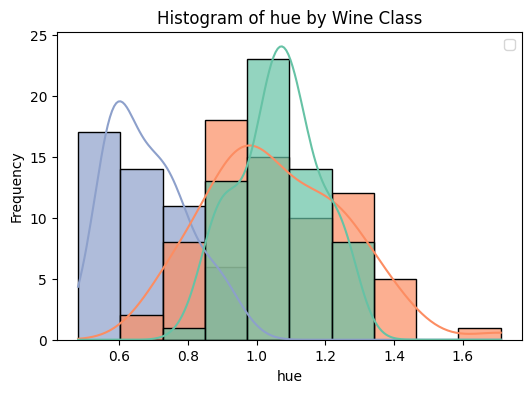

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


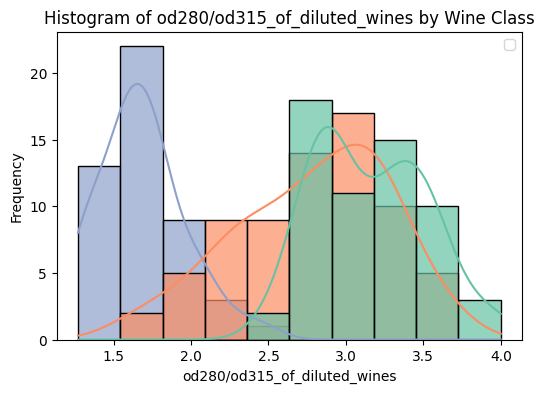

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


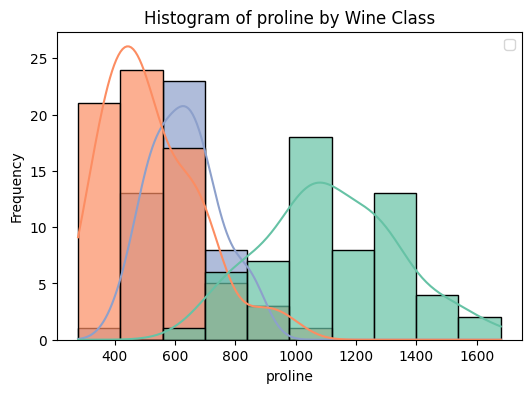

In [8]:
for col in data.drop(columns=['Class']):  
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(data=data, x=col, hue="Class", bins=10, kde=True, palette="Set2", alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col} by Wine Class")
    plt.legend()
    plt.show()



---

# Correlation

<Axes: >

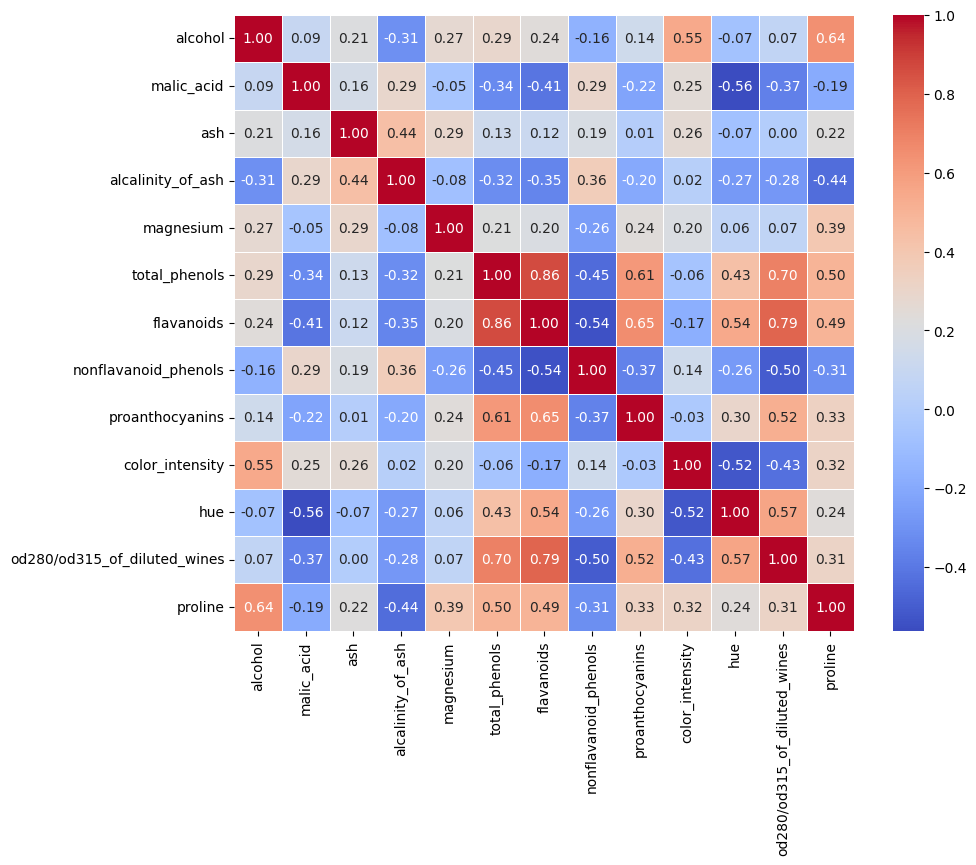

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

---

# BoxPlot

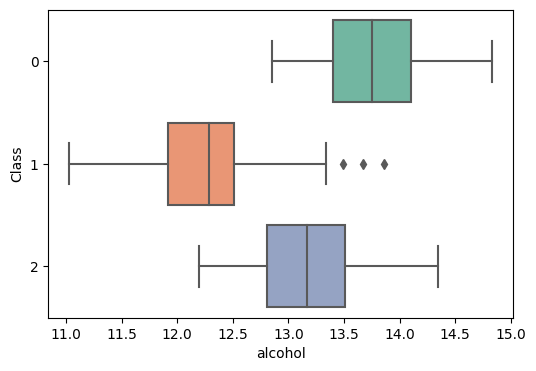

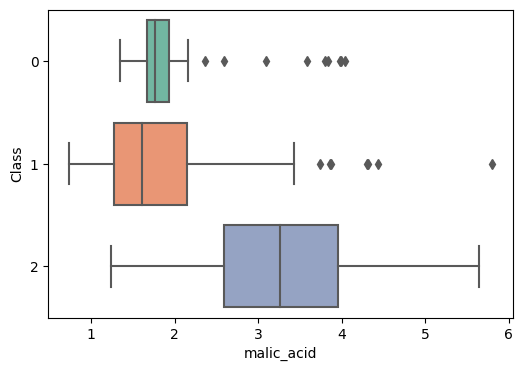

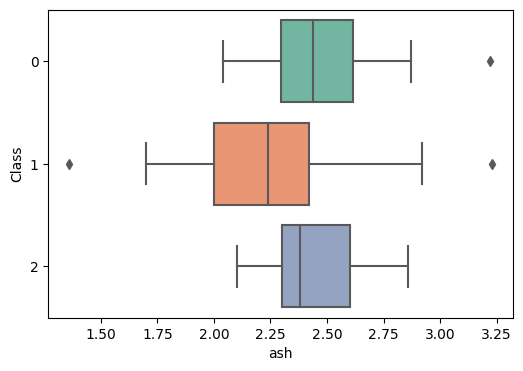

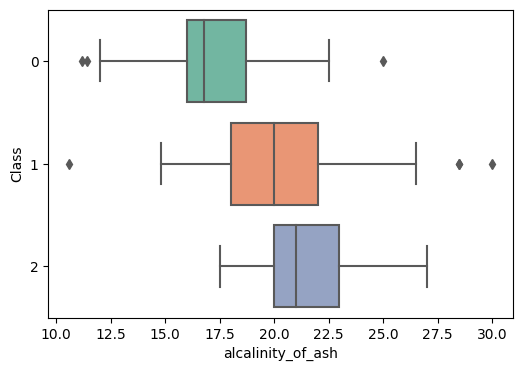

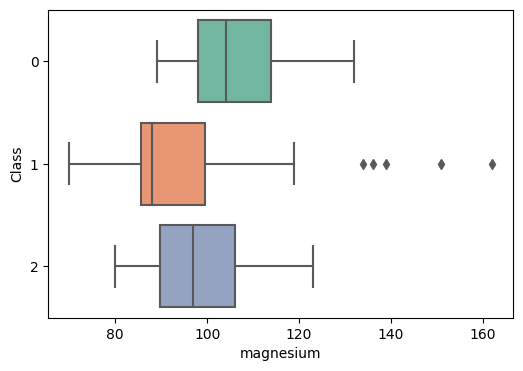

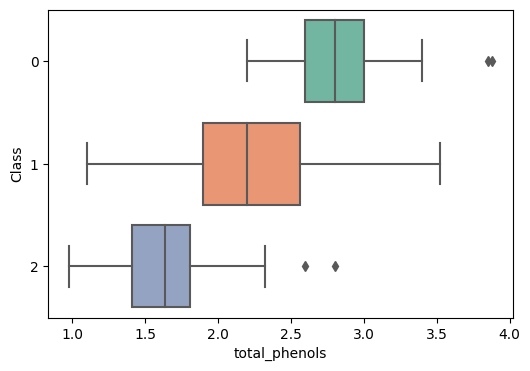

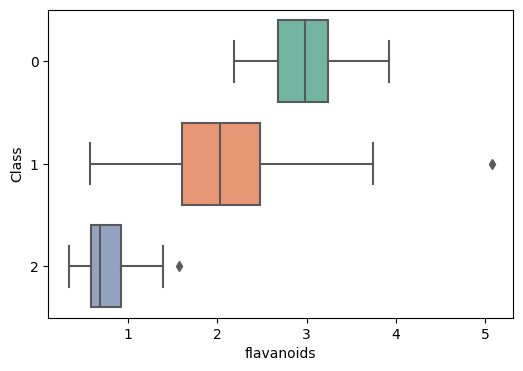

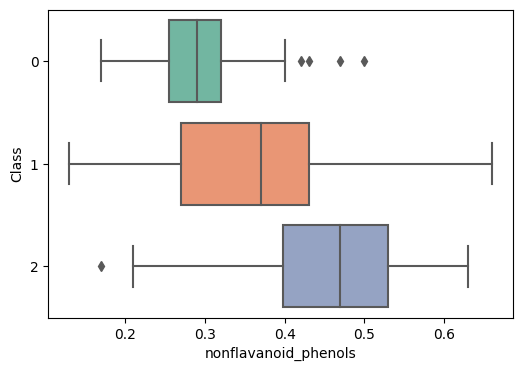

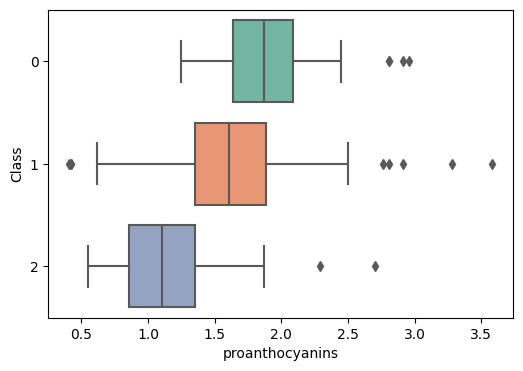

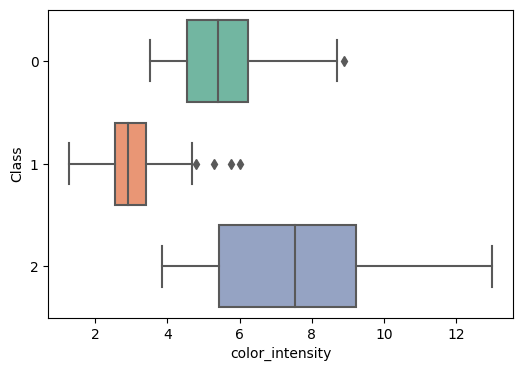

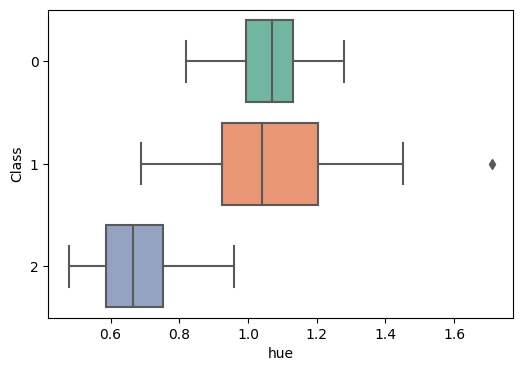

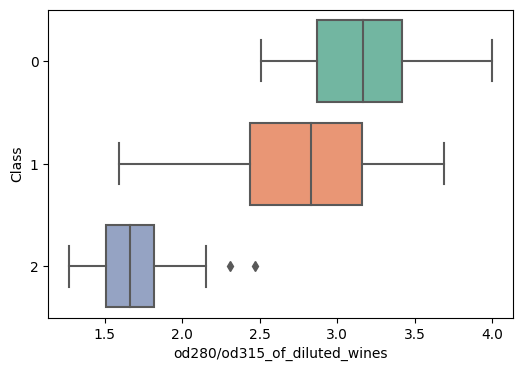

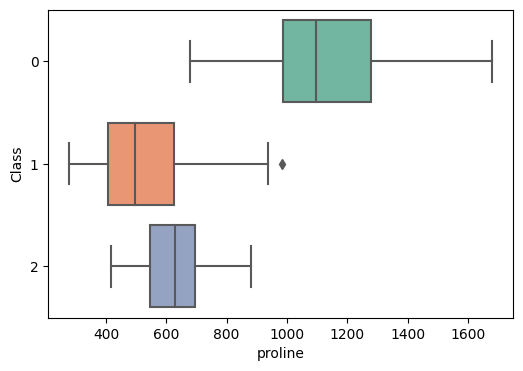

In [10]:
for i in features.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=i, y='Class', data=data, palette="Set2", orient="h")

    plt.xlabel(i)
    plt.ylabel("Class")

    plt.show()

In [11]:
X = features.drop(columns=['ash'])
y = target

---

# PCA

In [12]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

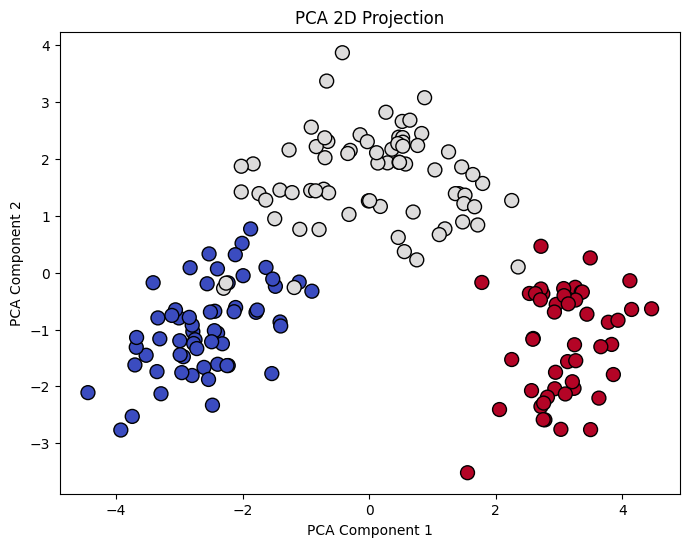

In [16]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=100)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA 2D Projection")

plt.show()


In [14]:
explained_variance = pca.explained_variance_ratio_
print(np.sum(explained_variance))

0.5737874490085584


In [15]:
pca1_weights = pca.components_[0]  

pca1_df = pd.DataFrame({'Feature': X.columns, 'PCA1 Weight': pca1_weights})
pca1_df["Abs Weight"] = np.abs(pca1_df["PCA1 Weight"]) 
pca1_df = pca1_df.sort_values(by="Abs Weight", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(pca1_df["Feature"], pca1_df["PCA1 Weight"], color="skyblue")
plt.xlabel("PCA1 Contribution")
plt.ylabel("Features")
plt.title("Feature Contribution to PCA1")
plt.gca().invert_yaxis() 
plt.show()


ValueError: All arrays must be of the same length

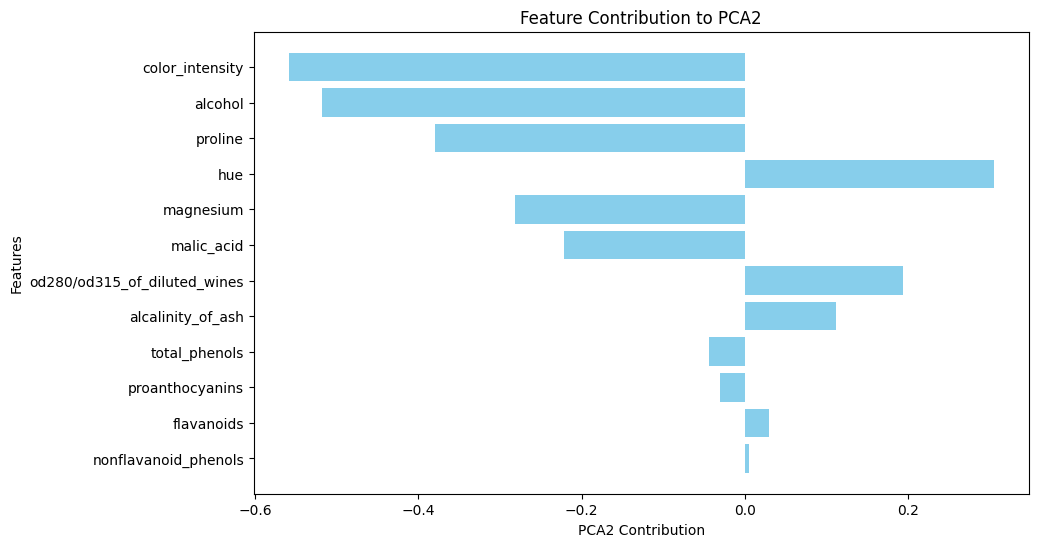

In [ ]:
pca2_weights = pca.components_[1]

pca2_df = pd.DataFrame({'Feature': X.columns, 'PCA2 Weight': pca2_weights})

pca2_df["Abs Weight"] = np.abs(pca2_df["PCA2 Weight"])  
pca2_df = pca2_df.sort_values(by="Abs Weight", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(pca2_df["Feature"], pca2_df["PCA2 Weight"], color="skyblue")
plt.xlabel("PCA2 Contribution")
plt.ylabel("Features")
plt.title("Feature Contribution to PCA2")
plt.gca().invert_yaxis()
plt.show()


---

# Logistic Regression without StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

lr = LogisticRegression(random_state=42) # max_iter=2739
model = lr.fit(X_train, y_train) 

y_pred = model.predict(X_test) # which class?
y_proba = model.predict_proba(X_test) # what probability in this class?

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Train Accuracy: 0.9648
Test Accuracy: 0.9722


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



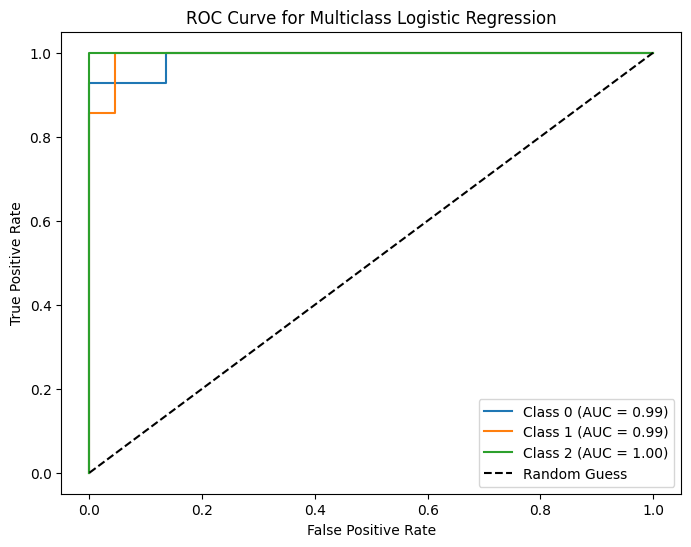

In [ ]:
# 放在第一行 結合兩張圖
plt.figure(figsize=(8, 6))

for i in range(y_proba.shape[1]): # 跌代3個class
    # 計算 ROC
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multiclass Logistic Regression")
plt.legend()
plt.show()

---

# Logistic Regression with StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# 數據單位差距過大，可考慮使用
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

lr = LogisticRegression(random_state=42, multi_class='ovr')
model2 = lr.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled) 
y_proba2 = model2.predict_proba(X_test_scaled)

train_score2 = model2.score(X_train_scaled, y_train)
test_score2 = model2.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_score2:.4f}")
print(f"Test Accuracy: {test_score2:.4f}")

Train Accuracy: 0.9859
Test Accuracy: 0.9722


In [ ]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.93      0.96        14
           2       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



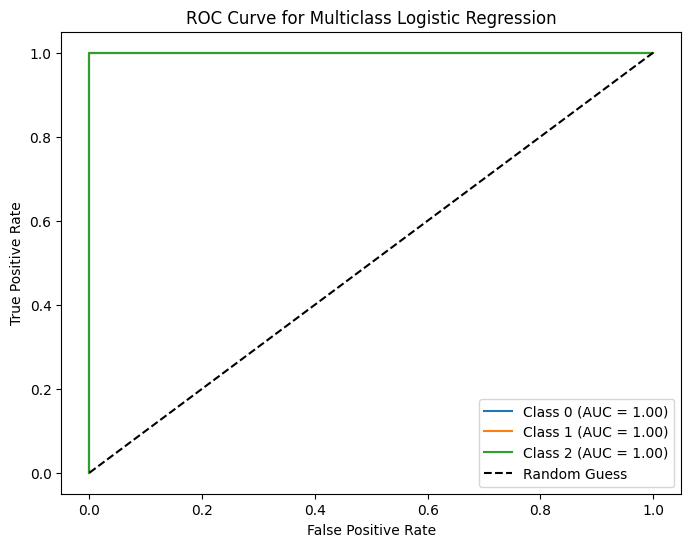

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(y_proba2.shape[1]): 
    fpr, tpr, _ = roc_curve(y_test == i, y_proba2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multiclass Logistic Regression")
plt.legend()
plt.show()

---

# Adaboost

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
abc = AdaBoostClassifier(random_state=42)
model3 = abc.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)
y_proba3 = model3.predict_proba(X_test)

train_score3 = model3.score(X_train, y_train)
test_score3 = model3.score(X_test, y_test)

print(f"Train Accuracy: {train_score3:.4f}")
print(f"Test Accuracy: {test_score3:.4f}")

Train Accuracy: 0.9225
Test Accuracy: 0.9167


In [ ]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.82      1.00      0.90        14
           2       1.00      0.88      0.93         8

    accuracy                           0.92        36
   macro avg       0.94      0.91      0.92        36
weighted avg       0.93      0.92      0.92        36



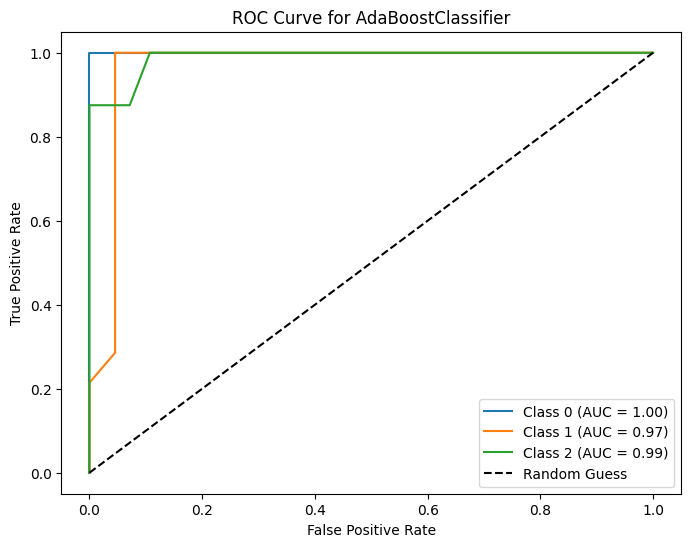

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(y_proba3.shape[1]):
    fpr, tpr, _ = roc_curve(y_test == i, y_proba3[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for AdaBoostClassifier")
plt.legend()
plt.show()

---

# GradientBoostingClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
gbc = GradientBoostingClassifier(random_state=42)
model4 = gbc.fit(X_train, y_train)

y_pred4 = model4.predict(X_test)
y_proba4 = model4.predict_proba(X_test)

train_score4 = model4.score(X_train, y_train)
test_score4 = model4.score(X_test, y_test)

print(f"Train Accuracy: {train_score4:.4f}")
print(f"Test Accuracy: {test_score4:.4f}")


Train Accuracy: 1.0000
Test Accuracy: 0.9444


In [ ]:
print(classification_report(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.93      0.93      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



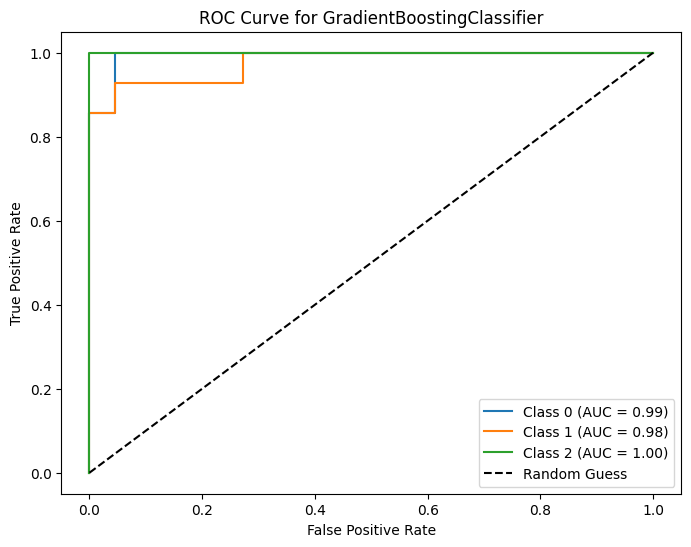

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(y_proba4.shape[1]): 
    fpr, tpr, _ = roc_curve(y_test == i, y_proba4[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for GradientBoostingClassifier")
plt.legend()
plt.show()

---

# DecisionTreeClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
dtc = DecisionTreeClassifier(random_state=42)
model5 = dtc.fit(X_train, y_train)

y_pred5 = model5.predict(X_test)
y_proba5 = model5.predict_proba(X_test)

train_score5 = model5.score(X_train, y_train)
test_score5 = model5.score(X_test, y_test)

print(f"Train Accuracy: {train_score5:.4f}")
print(f"Test Accuracy: {test_score5:.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.9444


In [ ]:
print(classification_report(y_test, y_pred5))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



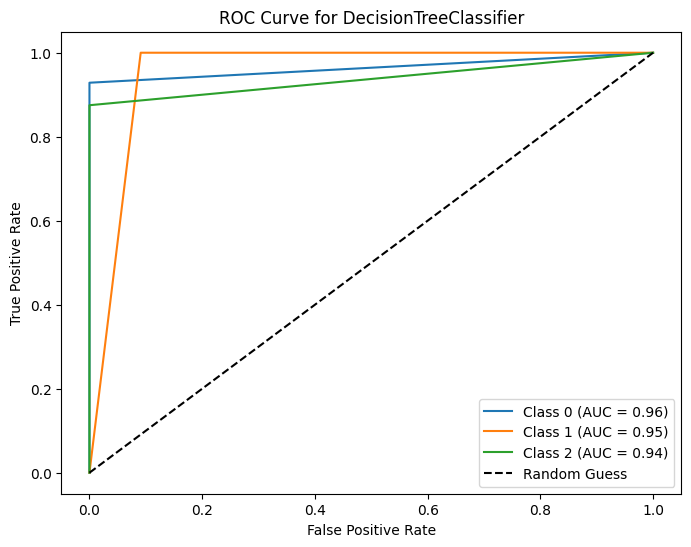

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(y_proba5.shape[1]): 
    fpr, tpr, _ = roc_curve(y_test == i, y_proba5[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for DecisionTreeClassifier")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
for i in range(y_proba.shape[1]):
    auc_score = roc_auc_score(y_test == i, y_proba[:, 1])
    print(f'Class {i}L Macro-Averaged AUC: {auc_score: .4f}')




Class 0L Macro-Averaged AUC:  0.2143
Class 1L Macro-Averaged AUC:  0.9935
Class 2L Macro-Averaged AUC:  0.2143


In [ ]:
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(y_test, y_proba5, multi_class="ovr", average="macro")
print(f"Macro-Averaged AUC: {macro_auc:.3f}")

Macro-Averaged AUC: 0.952


In [ ]:
results = pd.DataFrame({'model':['LR', 'LRxScaler', 'Adaboost', 'GrandientBoost', 'DecisionTree'], 
                        'Train':[train_score, train_score2, train_score3, train_score4, train_score5],
                        'Test':[test_score, test_score2, test_score3, test_score4, test_score5]})
results

,model,Train,Test
0,LR,0.964789,0.972222
1,LRxScaler,0.985915,0.972222
2,Adaboost,0.922535,0.916667
3,GrandientBoost,1.000000,0.944444
4,DecisionTree,1.000000,0.944444
